## 2D Orzag-Tang vortex evolution

In this example we simulate a modified Orzag-Tang vortex (given in *Loureiro et al. 2016, Comput. Phys. Commun. 206 (2016): 45-63*):

$\Phi = \cos(x+1.4) + \cos(y + 0.5), \quad \Psi = \cos(2x+2.3)+\cos(x+4.1)$

In [1]:
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
jr.init_cluster()

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 1


In [2]:
#parameters
nx = 256
ny = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
dx = Lx/nx
dt = 0.01
t = 0.0
nsnap = 100
t_snap=0.1
t_end=10.0
cfl_safety=1.0 #this is pretty aggressive
spatial_dimensions=2
snap_path="data/orzag-tang-2D/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)
psi = jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

In [ ]:
#do the simulation
_=jr.simulate(state,kgrid,params,t_snap=t_snap,t_end=t_end,mngr=mngr,shardings=shardings)

Saving initial state as snapshot 0
---COMPILING rk_advance---
Saving snapshot 1 at t = 0.10152904882927274
---COMPILING rk_advance---
Saving snapshot 2 at t = 0.20963404199992486
Saving snapshot 3 at t = 0.3153352815322792
Saving snapshot 4 at t = 0.41768297280973
Saving snapshot 5 at t = 0.5232658213509032
Saving snapshot 6 at t = 0.6234271455889815
Saving snapshot 7 at t = 0.7245137444198183
Saving snapshot 8 at t = 0.8256535762827214
Saving snapshot 9 at t = 0.9265196916620023
Saving snapshot 10 at t = 1.0309434062697302
Saving snapshot 11 at t = 1.1339194209324186
Saving snapshot 12 at t = 1.2377580145533595
Saving snapshot 13 at t = 1.3392833023798747
Saving snapshot 14 at t = 1.4400291582824325
Saving snapshot 15 at t = 1.5414879469711757
Saving snapshot 16 at t = 1.6441538611780329
Saving snapshot 17 at t = 1.7465624855179165
Saving snapshot 18 at t = 1.8504087160800462
Saving snapshot 19 at t = 1.9540982450414441
Saving snapshot 20 at t = 2.0559437829668408
Saving snapshot 21 a

SimulationState(t=Array(10.02387314, dtype=float64), fields=Fields(phik=Array([[-3.65496522e-12   +0.j        ,  1.05971635e+04+3669.84881216j,
         7.62960615e+02 +820.19435853j, ...,
         0.00000000e+00   +0.j        ,  0.00000000e+00   +0.j        ,
         0.00000000e+00   +0.j        ],
       [-6.15270615e+03+7346.8347508j , -3.42856390e+03-3872.65259024j,
         1.61818623e+03+2159.11121141j, ...,
         0.00000000e+00   +0.j        ,  0.00000000e+00   +0.j        ,
         0.00000000e+00   +0.j        ],
       [-1.08610181e+03 +385.94872493j, -2.02390042e+03 -770.74054615j,
         4.39288208e+02 -365.05640421j, ...,
         0.00000000e+00   +0.j        ,  0.00000000e+00   +0.j        ,
         0.00000000e+00   +0.j        ],
       ...,
       [ 7.21545839e+02 +560.14453908j, -7.83038447e+01  +90.90930608j,
         1.58241389e+02  +56.40289804j, ...,
         0.00000000e+00   +0.j        ,  0.00000000e+00   +0.j        ,
         0.00000000e+00   +0.j       

In [4]:
#Making some snapshots.
for isnap in range(0,99):
    snap=sn.load_snapshot(isnap,mngr,params,shardings)
    #vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    #vsq=jnp.sum(jnp.array(jax.tree_util.tree_map(lambda gfk: ft.irfft2(gfk),gradk(snap.fields.phik,kgrid)))**2.0,axis=0)
    vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    plt.imshow(vort,vmin=-50,vmax=50,cmap="afmhot")
    plt.colorbar()
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')

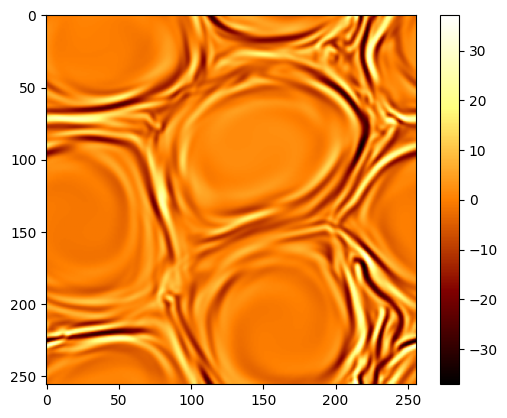

In [8]:
#Plot one of them here
isnap=50
snap=sn.load_snapshot(isnap,mngr,params,shardings)
vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
plt.imshow(vort,cmap="afmhot")
plt.colorbar()

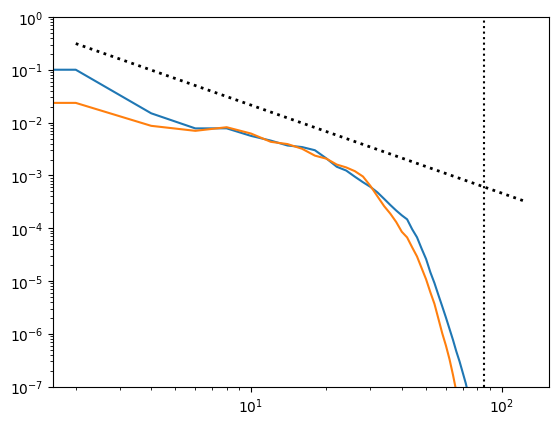

In [3]:
#plot the energy spectrum
isnap=50
snap=sn.load_snapshot(isnap,mngr,params,shardings)
k=jnp.array(range(0,params.nx//2,2)) # bin_factor in the spec routine is set to 2 by default
bins,su,sb=diag.perpspec(snap,kgrid,params)
plt.loglog(k,sb)
plt.loglog(k,su)
plt.ylim(1e-7,1)
plt.loglog(k,k**(-5.0/3.0),'k:',linewidth=2)
plt.loglog([params.nx//3,params.nx//3],[1e-7,1],'k:')

In [7]:
#This makes a gif of the snapshot images if you have imagemagick installed
os.system("cd " + snap_path + ";"
          + "magick -delay 1 -loop 0 *.png orzag-tang-2D.gif;"
         + "cd ../../")

0

Things to mess with if you want to:
- Experiment with different dissipation parameters `visc`,`res`,`hyper`
- Check how the energy in the box evolves (There is a function `energy` in `jax_rmhd.diagnostics.py`)